# Housing Price Prediction

A portfolio-ready machine learning project using the Kaggle **House Prices: Advanced Regression Techniques** dataset.

## Project Goals
- Explore the housing dataset with clear visualizations.
- Clean missing values and reduce the effect of outliers.
- Engineer meaningful features such as house age and total square footage.
- Train and compare three regression models:
  - Linear Regression
  - Random Forest Regressor
  - Gradient Boosting Regressor
- Evaluate models using MAE, RMSE, and R².
- Interpret the models with feature importance.


## Dataset Setup

1. Download the Kaggle dataset: [House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)
2. Create a folder named `data` in the project root.
3. Place `train.csv` inside `data/`.

Expected path:

```text
./data/train.csv
```


In [1]:
# Core libraries for data manipulation, visualization, and modeling
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
from pathlib import Path
import pandas as pd

possible_paths = [
    Path(r"C:\Users\IBM\OneDrive\Documentos\data\train.csv"),
    Path("data/train.csv"),
]

data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("Could not find train.csv in the expected locations.")

df = pd.read_csv(data_path)
print("Using:", data_path)
print(df.shape)
df.head()


Using: C:\Users\IBM\OneDrive\Documentos\data\train.csv
(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Check missing values to understand data quality before preprocessing
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame('missing_count')
)
missing_summary['missing_pct'] = 100 * missing_summary['missing_count'] / len(df)
missing_summary[missing_summary['missing_count'] > 0].head(20)


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


## Exploratory Data Analysis

This section focuses on the target variable, relationships with key predictors, and broad correlation patterns among numeric features.


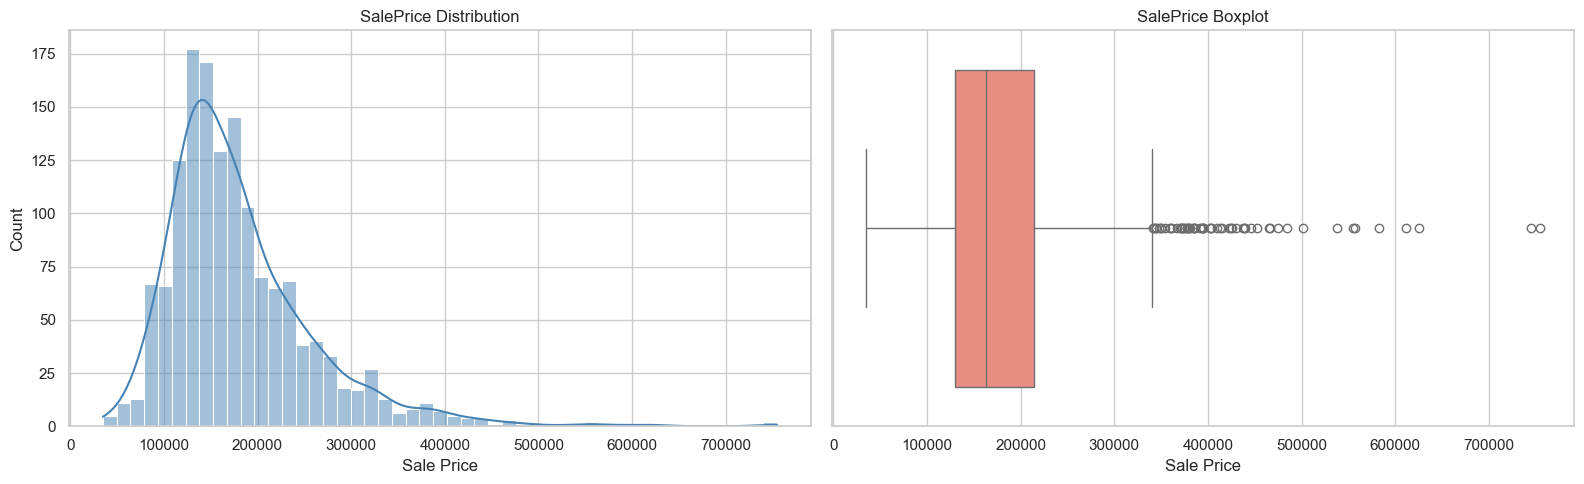

In [4]:
# Visualize the target distribution to inspect skewness and spread
import matplotlib.pyplot as plt
import seaborn as sns

if 'SalePrice' not in df.columns:
    raise KeyError("The column 'SalePrice' was not found in the dataset.")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('Sale Price')
axes[0].set_ylabel('Count')

sns.boxplot(x=df['SalePrice'], ax=axes[1], color='salmon')
axes[1].set_title('SalePrice Boxplot')
axes[1].set_xlabel('Sale Price')

plt.tight_layout()
plt.show()



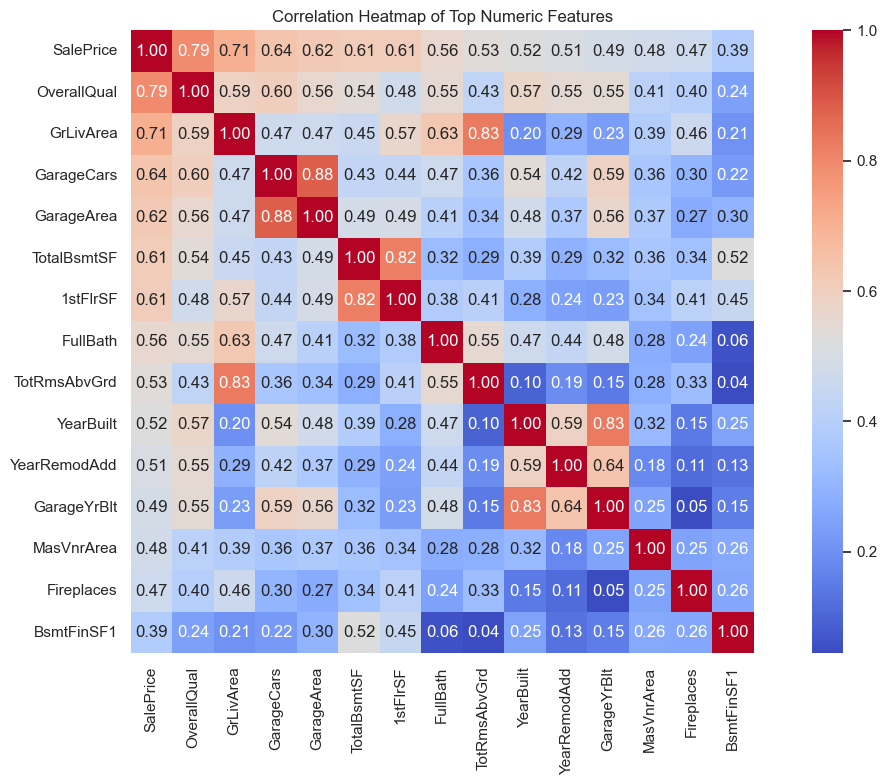

In [5]:
# Plot a correlation heatmap using the numeric features most related to the target
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])
top_corr_features = (
    numeric_df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)
corr_matrix = numeric_df[top_corr_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Top Numeric Features")
plt.tight_layout()
plt.show()



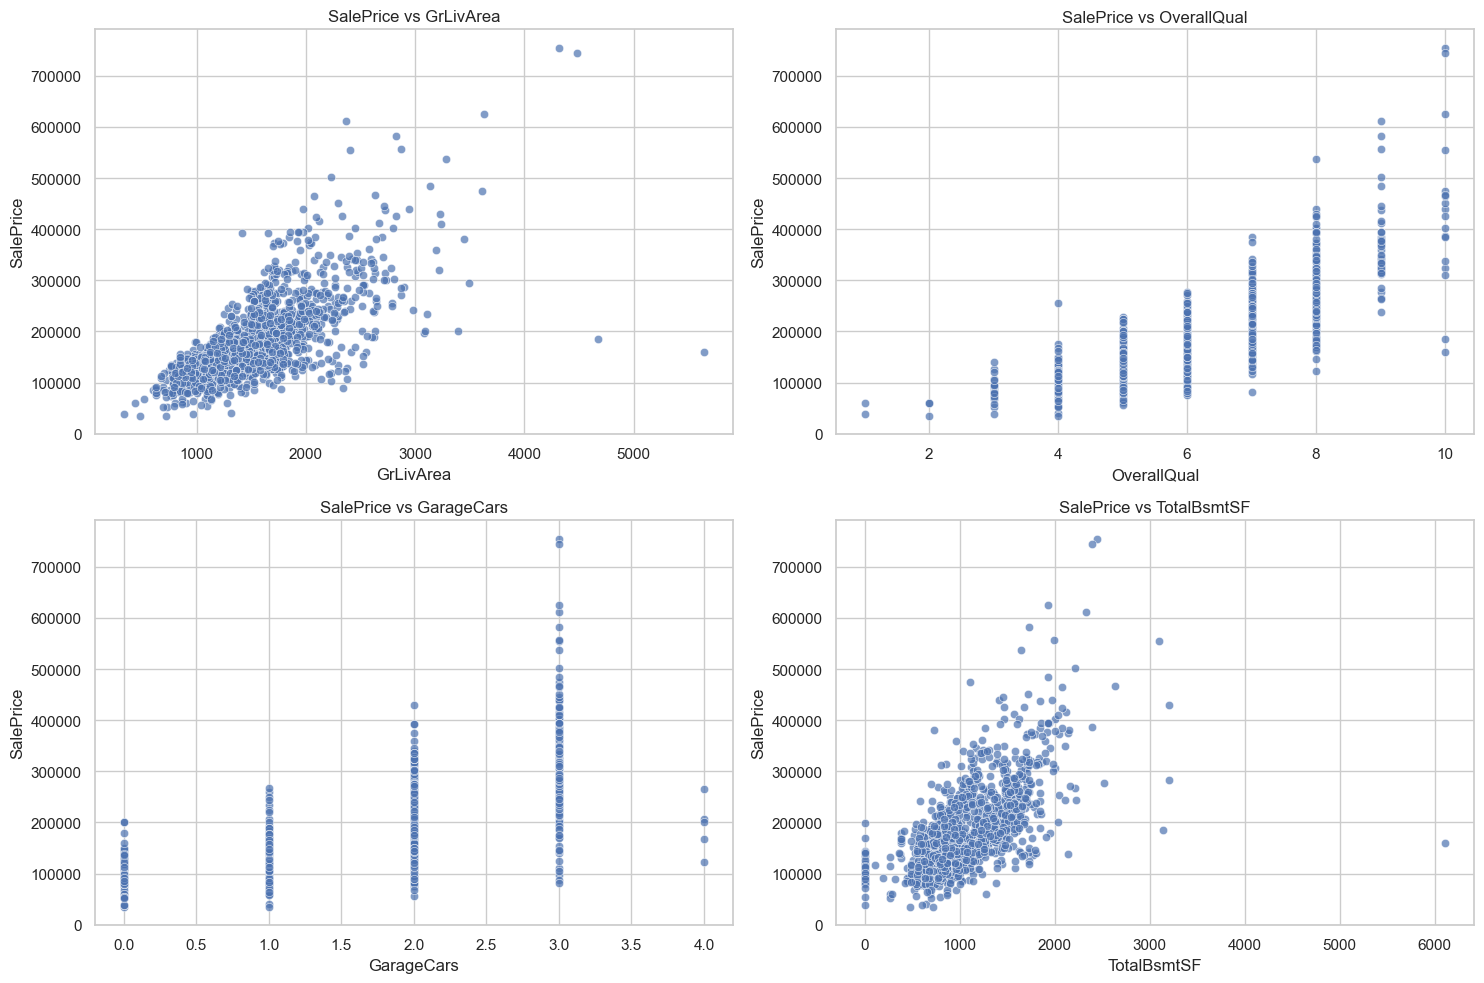

In [6]:
# Scatter plots highlight how a few important predictors relate to sale price
key_features = ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, feature in zip(axes.flatten(), key_features):
    sns.scatterplot(data=df, x=feature, y='SalePrice', ax=ax, alpha=0.7)
    ax.set_title(f'SalePrice vs {feature}')

plt.tight_layout()


## Data Cleaning and Feature Engineering

The dataset includes missing values, a few extreme outliers, and opportunities to create more informative variables from the original columns.


In [7]:
# Remove a small number of extreme living-area outliers that can distort training
df_clean = df.copy()
outlier_mask = (df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)
print(f'Removing {outlier_mask.sum()} extreme outliers from the training data.')
df_clean = df_clean.loc[~outlier_mask].copy()
print(f'Cleaned dataset shape: {df_clean.shape}')


Removing 2 extreme outliers from the training data.
Cleaned dataset shape: (1458, 81)


In [8]:
# Create new features that summarize age, size, and bathroom count more effectively
def engineer_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    engineered = dataframe.copy()
    engineered['HouseAge'] = engineered['YrSold'] - engineered['YearBuilt']
    engineered['RemodAge'] = engineered['YrSold'] - engineered['YearRemodAdd']
    engineered['TotalSF'] = (
        engineered['TotalBsmtSF'].fillna(0)
        + engineered['1stFlrSF'].fillna(0)
        + engineered['2ndFlrSF'].fillna(0)
    )
    engineered['TotalBath'] = (
        engineered['FullBath'].fillna(0)
        + 0.5 * engineered['HalfBath'].fillna(0)
        + engineered['BsmtFullBath'].fillna(0)
        + 0.5 * engineered['BsmtHalfBath'].fillna(0)
    )
    engineered['HasGarage'] = np.where(engineered['GarageArea'].fillna(0) > 0, 1, 0)
    return engineered

df_features = engineer_features(df_clean)
df_features[['HouseAge', 'RemodAge', 'TotalSF', 'TotalBath', 'HasGarage']].head()


,HouseAge,RemodAge,TotalSF,TotalBath,HasGarage
0,5,5,2566,3.50,1
1,31,31,2524,2.50,1
2,7,6,2706,3.50,1
3,91,36,2473,2.00,1
4,8,8,3343,3.50,1


In [9]:
# Select relevant features by removing ID fields and columns with excessive missingness
target = 'SalePrice'
id_column = 'Id'
missing_threshold = 0.40

feature_data = df_features.drop(columns=[target, id_column])
missing_ratio = feature_data.isna().mean().sort_values(ascending=False)
selected_columns = missing_ratio[missing_ratio <= missing_threshold].index.tolist()

X = feature_data[selected_columns].copy()
y = df_features[target].copy()

print(f'Number of selected features: {len(selected_columns)}')
display(pd.DataFrame({'feature': selected_columns}).head(15))


Number of selected features: 78


,feature
0,LotFrontage
1,GarageFinish
2,GarageYrBlt
3,GarageType
4,GarageCond
5,GarageQual
6,BsmtFinType2
7,BsmtExposure
8,BsmtFinType1
9,BsmtCond


In [10]:
# Split the data into training and validation sets for fair model comparison
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 41
Categorical features: 37


In [11]:
# Build preprocessing pipelines for numeric and categorical columns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## Model Training and Evaluation

Each model is trained using the same train/validation split and preprocessing pipeline so the comparison stays consistent.


In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [14]:
# Define the models to compare
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_pipelines = {}
results = []

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_valid)

    mae = mean_absolute_error(y_valid, predictions)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    r2 = r2_score(y_valid, predictions)

    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
results_df.style.format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'R2': '{:.4f}'})


,Model,MAE,RMSE,R2
0,Gradient Boosting,"14,210.17","20,246.76",0.9258
1,Random Forest,"16,425.18","24,393.10",0.8923
2,Linear Regression,"17,738.91","25,398.36",0.8832


C:\Users\IBM\AppData\Local\Temp\ipykernel_26976\3507772992.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\IBM\AppData\Local\Temp\ipykernel_26976\3507772992.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\IBM\AppData\Local\Temp\ipykernel_26976\3507772992.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x='Model', y=metric, ax=ax, palette='viridis')


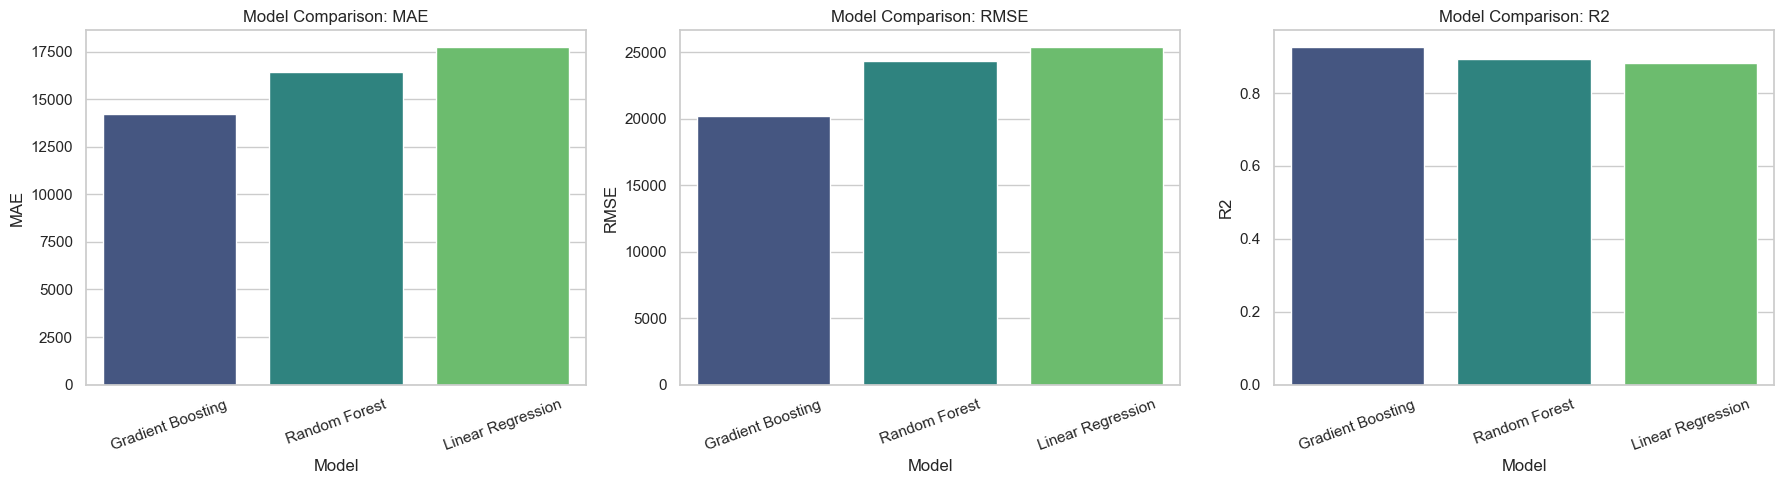

In [15]:
# Visual comparison of the models across the main evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_names = ['MAE', 'RMSE', 'R2']

for ax, metric in zip(axes, metric_names):
    order = results_df.sort_values(metric, ascending=(metric != 'R2'))
    sns.barplot(data=order, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(f'Model Comparison: {metric}')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()


## Feature Importance and Model Interpretation

Feature importance helps explain which predictors matter most. For Linear Regression, we use the largest absolute coefficients. For tree-based models, we use built-in feature importances.


In [16]:
# Helper function to extract transformed feature names from the fitted preprocessor
def get_transformed_feature_names(fitted_pipeline: Pipeline) -> np.ndarray:
    fitted_preprocessor = fitted_pipeline.named_steps['preprocessor']
    return fitted_preprocessor.get_feature_names_out()


def plot_feature_importance(fitted_pipeline: Pipeline, model_name: str, top_n: int = 15) -> pd.DataFrame:
    model = fitted_pipeline.named_steps['model']
    feature_names = get_transformed_feature_names(fitted_pipeline)

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_)
    else:
        raise ValueError(f'Feature importance is not available for {model_name}.')

    importance_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')
    plt.title(f'Top {top_n} Features - {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()

    return importance_df


C:\Users\IBM\AppData\Local\Temp\ipykernel_26976\2497873292.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')


,feature,importance
110,cat__SaleType_New,"88,040.45"
134,cat__Condition2_RRAe,"78,934.35"
103,cat__SaleCondition_Partial,"74,479.54"
55,cat__GarageQual_Ex,"70,867.84"
50,cat__GarageCond_Ex,"58,583.43"
202,cat__RoofMatl_WdShngl,"57,714.05"
132,cat__Condition2_PosA,"55,813.66"
196,cat__RoofStyle_Shed,"55,134.81"
228,cat__Exterior1st_ImStucc,"41,753.18"
168,cat__Neighborhood_StoneBr,"40,568.68"


C:\Users\IBM\AppData\Local\Temp\ipykernel_26976\2497873292.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')


,feature,importance
13,num__TotalSF,0.44
31,num__OverallQual,0.34
28,num__GrLivArea,0.02
15,num__HouseAge,0.01
12,num__TotalBath,0.01
39,num__BsmtFinSF1,0.01
29,num__YearBuilt,0.01
10,num__GarageArea,0.01
32,num__LotArea,0.01
4,num__GarageCars,0.01


C:\Users\IBM\AppData\Local\Temp\ipykernel_26976\2497873292.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='mako')


,feature,importance
13,num__TotalSF,0.43
31,num__OverallQual,0.30
12,num__TotalBath,0.03
15,num__HouseAge,0.02
4,num__GarageCars,0.02
28,num__GrLivArea,0.02
80,cat__BsmtQual_Ex,0.02
39,num__BsmtFinSF1,0.02
43,cat__GarageFinish_Unf,0.01
32,num__LotArea,0.01


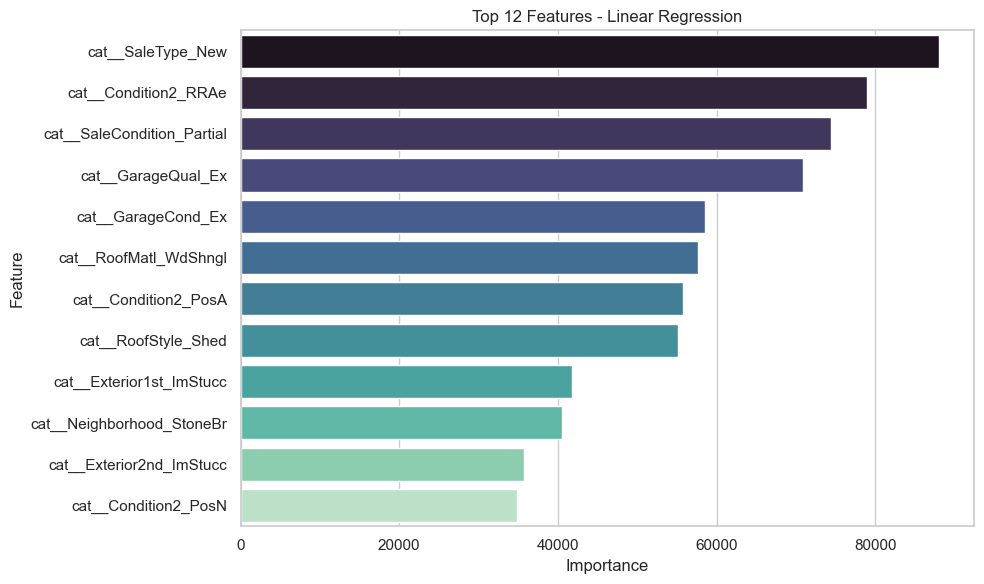

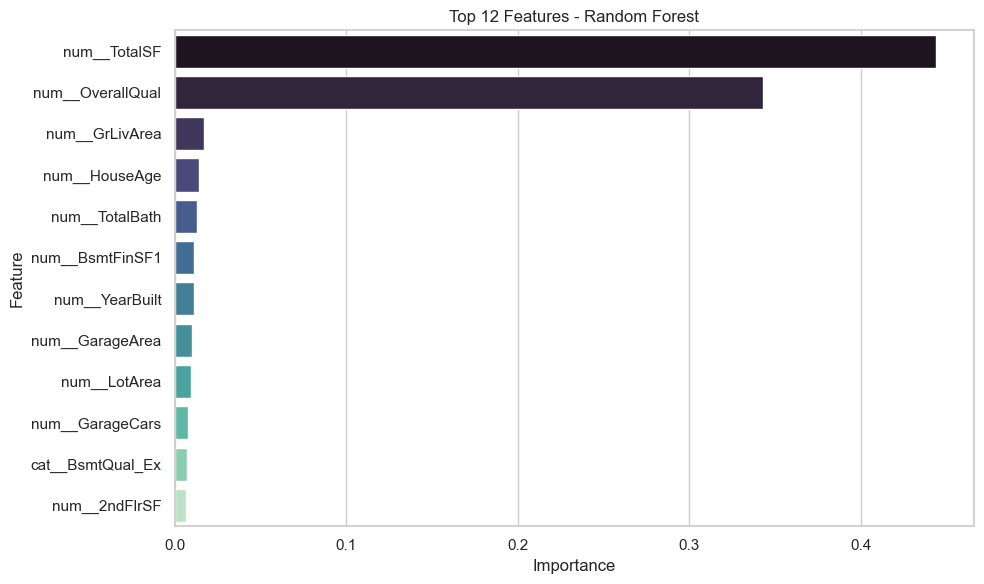

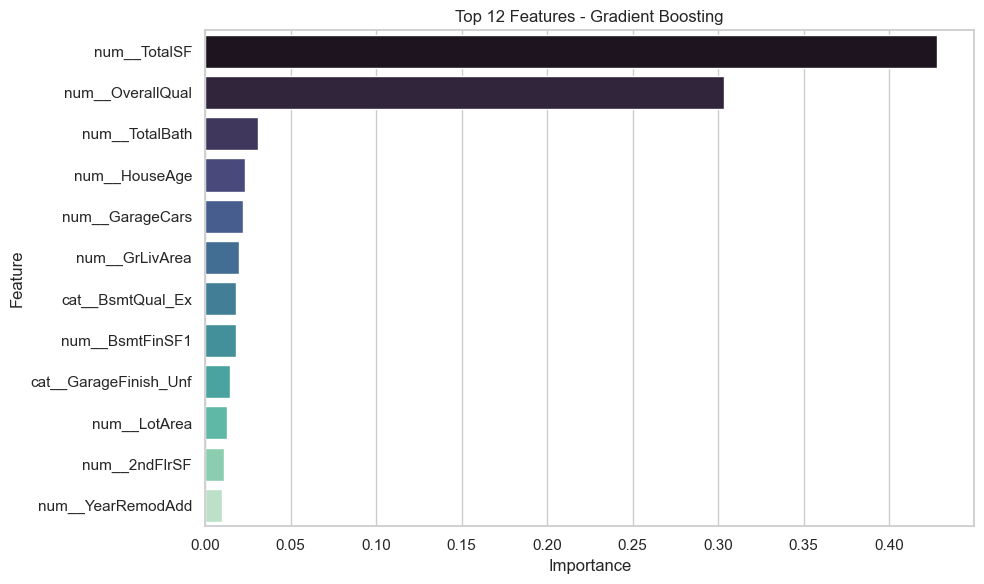

In [17]:
# Review the most influential features for each model
for model_name, fitted_pipeline in trained_pipelines.items():
    display(plot_feature_importance(fitted_pipeline, model_name, top_n=12))


In [18]:
# Show the best-performing model based on RMSE
best_model_name = results_df.iloc[0]['Model']
print(f'Best model by RMSE: {best_model_name}')
results_df.head(1)


Best model by RMSE: Gradient Boosting


,Model,MAE,RMSE,R2
0,Gradient Boosting,"14,210.17","20,246.76",0.93


## Conclusion

This notebook demonstrates a complete regression workflow for predicting housing prices:

- Performed EDA with target distribution, correlation heatmap, and scatter plots.
- Cleaned the data by addressing missing values and removing extreme outliers.
- Engineered new features to better represent home age, total square footage, and bathrooms.
- Trained and compared three regression models with consistent preprocessing.
- Interpreted the results using feature importance and validation metrics.

This makes a strong portfolio project because it combines business understanding, data cleaning, visualization, predictive modeling, and interpretability in one clear workflow.
